# Exploratory Data Analysis - Welltory Data Set

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_hrv = pd.read_csv('hrv_measurements.csv')
df_partic = pd.read_csv('participants.csv')

## Understanding the data
### Welltory Data Set Context
Voluntary data from app users participating in a project, so not a random sample.

### Questions we are asking:
* What are the dimensions of the dataset (number of rows and columns)?
* What are the data types of the variables (numerical, categorical, text, etc.)?
* Are there any missing values, and if so, how are they represented?


I'm doing this for the hrv and participant tables since those tables seemed to have the most relevant info from my initial look at the repo. To replicate, copy the 'hrv_measurements.csv' and 'participants.csv' files from https://github.com/Welltory/hrv-covid19 into the week4 directory.

In [41]:
def get_df_basic_info(df):
    # Data Structure
    print("Data Structure")
    print("---------------")
    print(f"Dimensions: {df.shape}")
    print(f"Data Types:\n{df.dtypes}")
    print(f"Missing Values:\n{df.isnull().sum()}")
    print(df.head(5))

print("HRV:")
get_df_basic_info(df_hrv)

print("Participants:")
get_df_basic_info(df_partic)

HRV:
Data Structure
---------------
Dimensions: (3245, 22)
Data Types:
user_code                object
rr_code                  object
measurement_datetime     object
time_of_day              object
bpm                       int64
meanrr                  float64
mxdmn                   float64
sdnn                    float64
rmssd                   float64
pnn50                   float64
mode                    float64
amo                     float64
lf                      float64
hf                      float64
vlf                     float64
lfhf                    float64
total_power             float64
how_feel                  int64
how_mood                  int64
how_sleep               float64
tags                     object
rr_data                  object
dtype: object
Missing Values:
user_code                  0
rr_code                    0
measurement_datetime       0
time_of_day                0
bpm                        0
meanrr                     0
mxdmn                

### Initial thoughts
* It appears we have 185 different users based on our participants data, and they have mostly complete info while some are missing city, country, height, and symptoms onset data
* We have 3245 different HRV measurement instances with 22 columns of data for each measurement, most of which are numerical.
* That means multiple measurements per user, though the distribution is currently unclear
* how_sleep is missing for about half of them, so it may be best to avoid that if possible
* Initially thinking it may be possible to create some feature based on user qualities, such as country (may indicate COVID strain variations) or age range

## Descriptive Statistics
### Questions we are asking:
* What are the central tendency measures (mean, median, mode) for numerical variables?
* What are the measures of dispersion (range, variance, standard deviation) for numerical variables?
* What is the distribution of the variables (normal, skewed, etc.)?


In [42]:
def print_descriptive_stats(df):
    name = [x for x in globals() if globals()[x] is df][0]
    print(name)

    # Descriptive Statistics
    print("\nDescriptive Statistics")
    print("----------------------")
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    print("Central Tendency Measures:")
    print(df[numeric_columns].describe().loc[['mean', '50%']])
    print("\nDispersion Measures:")
    print(df[numeric_columns].describe().loc[['std', 'min', 'max']])

    # Check for distribution normality (skewness and kurtosis)
    print("\nDistribution Measures:")
    print("------------------------")
    print(df[numeric_columns].skew())
    print(df[numeric_columns].kurt())

print_descriptive_stats(df_hrv)
print_descriptive_stats(df_partic)

df_hrv

Descriptive Statistics
----------------------
Central Tendency Measures:
            bpm      meanrr     mxdmn       sdnn      rmssd      pnn50  \
mean  73.257935  839.600366  0.184635  52.489218  52.814196  20.615609   
50%   72.000000  829.100000  0.160000  46.919000  42.869000  16.160000   

          mode       amo          lf           hf         vlf      lfhf  \
mean  0.837465  46.78829  927.038213  1125.041294  578.229892  2.397769   
50%   0.825000  45.00000  423.000000   380.000000  293.000000  0.862000   

      total_power  how_feel  how_mood  how_sleep  
mean  2630.309399 -0.235439 -0.076733  -0.065484  
50%   1387.000000  0.000000  0.000000   0.000000  

Dispersion Measures:
            bpm       meanrr     mxdmn        sdnn       rmssd      pnn50  \
std   12.201088   137.420367  0.107456   29.369506   39.353213  18.588156   
min   44.000000   477.730000  0.030000    9.515000    6.340000   0.000000   
max  125.000000  1346.740000  0.790000  206.631000  310.800000  

## Interpretation

#### Descriptive Statistics
Mean heart rate (bpm) is 73.26 which is slightly higher than the median, meaning the data is right skewed. Without too much time and context knowledge, it's difficult to make judgements on the other statistics.

## Missing Values
* From our initial look at the dataset, we see 'how_sleep' is missing for about half of all the entries. We should drop it since it likely won't be important for our analysis purposes, and filling in with values might be misleading.
* There's 2 missing heights, which we can fill with median (rather than mean, which is more affected by outliers). Another column can be added to show if the height was filled in by us
* Median filling will reduce variation and likely wrong for those individuals, so any feature using their height will also be an estimate

In [ ]:
# use new df_process variables so original data is untouched
df_hrv_process = df_hrv.drop(columns="how_sleep")

df_partic_process = df_partic
df_partic_process["height_was_missing"] = df_partic_process["height"].isna()
median_height = df_partic_process["height"].median()
df_partic_process["height"] = df_partic_process["height"].fillna(median_height)

print("Filled in height:", median_height, "cm")
print("Missing heights after filling:", df_partic_process["height"].isna().sum())

Filled in height: 168.0 cm
Missing heights after filling: 0


## Duplicate Rows
We should check for exactly duplicated rows. Note, we do expect the user_code to repeat across rows in the HRV data since there are multiple measurements for the same user, so those shouldn't be interpreted as duplicates.

In [31]:
print("Exact duplicate HRV rows:", df_hrv.duplicated().sum())
print("Exact duplicate participant rows:", df_partic.duplicated().sum())

Exact duplicate HRV rows: 0
Exact duplicate participant rows: 0


No duplicates found in either table

## Data transform + New Feature
* The 'measurement_datetime' column could be transformed into a Pandas datetime so it's easier to process.
* A simple feature that could be added is BMI. It gives us a familiar/somewhat interpretable number to evaluate someone's health
* BMI = weight (kg) / height^2 (m)

In [ ]:
df_hrv_process["measurement_datetime"] = pd.to_datetime(df_hrv_process["measurement_datetime"])
print("Date range:", df_hrv_process["measurement_datetime"].min(), "to", df_hrv_process["measurement_datetime"].max())

# height is in cm so divide by 100 to get m
df_partic_process["bmi"] = df_partic_process["weight"] / (df_partic_process["height"] / 100) ** 2
display(df_partic_process[["height", "weight", "height_was_missing", "bmi"]].head())
display(df_partic_process["bmi"].describe().round(2))

Date range: 2019-12-31 06:08:29 to 2020-06-19 11:40:13


,height,weight,height_was_missing,bmi
0,170.18,96.162,False,33.203698
1,174.00,77.300,False,25.531774
2,178.00,92.000,False,29.036738
3,169.00,60.000,False,21.007668
4,158.00,68.500,False,27.439513


count    185.00
mean      27.14
std        7.14
min       13.14
25%       22.31
50%       26.24
75%       30.35
max       54.28
Name: bmi, dtype: float64

## Outliers
Looking at the RMSSD column, we can investigate outliers using a box plot

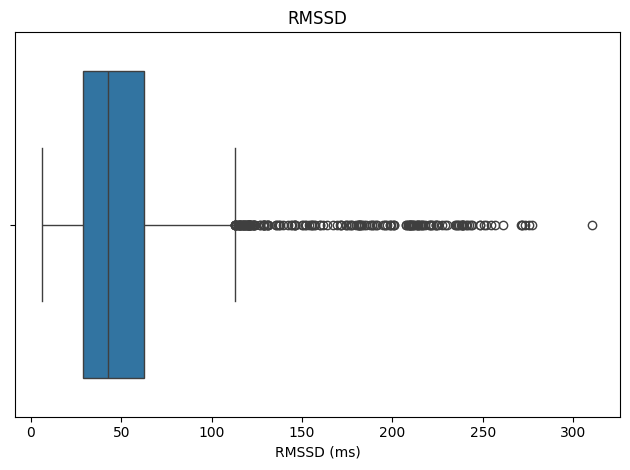

In [35]:
import seaborn as sns

plt.figure()
sns.boxplot(x=df_hrv_process["rmssd"])
plt.xlabel("RMSSD (ms)")
plt.title("RMSSD")
plt.tight_layout()
plt.show()

### Interpretation
From this we can see a reasonable number of outliers above the 75th percentile. Further analysis below to see how this affects the data.

In [36]:
q1 = df_hrv_process["rmssd"].quantile(0.25)
q3 = df_hrv_process["rmssd"].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

df_hrv_process["rmssd_outlier"] = (df_hrv_process["rmssd"] < lower_limit) | (df_hrv_process["rmssd"] > upper_limit)
print("IQR limits:", round(lower_limit, 2), "to", round(upper_limit, 2), "ms")
print("Flagged measurements:", df_hrv_process["rmssd_outlier"].sum())
print("Median with all values:", round(df_hrv_process["rmssd"].median(), 2))
print("Median without flagged values:", round(df_hrv_process.loc[~df_hrv_process["rmssd_outlier"], "rmssd"].median(), 2))

IQR limits: -21.26 to 112.74 ms
Flagged measurements: 195
Median with all values: 42.87
Median without flagged values: 41.14


### Interpretation
195/3245 (~6%) RMSSD are outliers. The median doesn't change too much when removing the outliers. We will assume the outliers are valid data entries and should not be removed, but this does give us a better picture of our right-skewed data.

## Visualize
Let's try a histogram

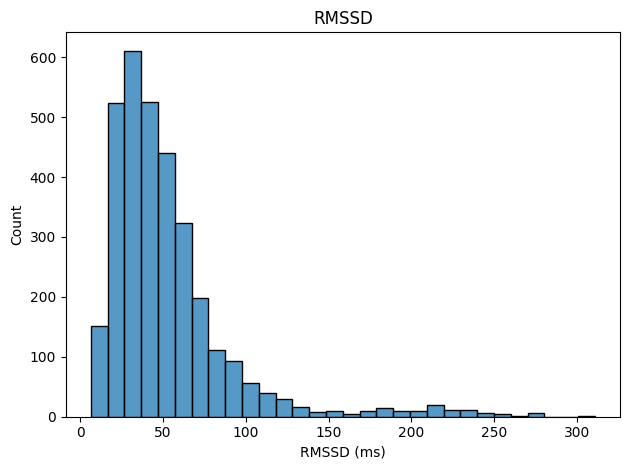

In [37]:
plt.figure()
sns.histplot(data=df_hrv_process, x="rmssd", bins=30)
plt.title("RMSSD")
plt.xlabel("RMSSD (ms)")
plt.tight_layout()
plt.show()

### Interpretation
From this we can see the right-skewed data.


Let's try a scatterplot to find the relationship between heart rate (bpm) and RMSSD

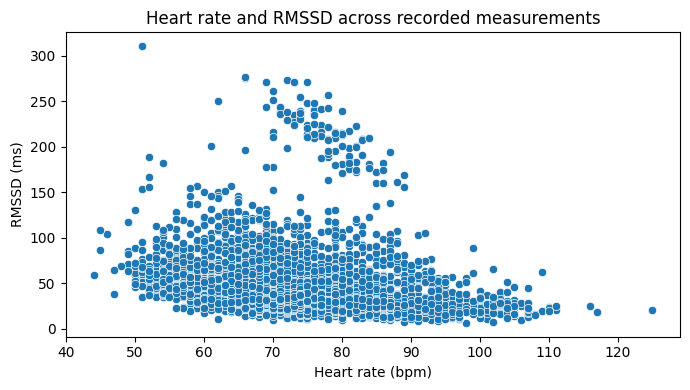

In [39]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df_hrv_process, x="bpm", y="rmssd")
plt.xlabel("Heart rate (bpm)")
plt.ylabel("RMSSD (ms)")
plt.title("Heart rate and RMSSD across recorded measurements")
plt.tight_layout()
plt.show()

### Interpretation
It seems like heart rate and RMSSD have a weak negative linear correlation (higher the heart rate, lower the RMSSD).
However, we should keep in mind the data may be skewed since certain individuals may have a higher number of measurements, skewing the data based on their measurements.

## Data quality assessment
* Data profiling: Used dimensions, column names, and types to understand the data
* Completeness: We were missing quite a bit of sleep data and ended up choosing to not use it as all. We filled in missing heights with the median and ensured the data filling was clear based on the added column
* Accuracy: It's difficult to judge because we don't have enough context on the measurements taken, but from the data we've seen, there was nothing that jumped out as inaccurate.
* Consistency: Our pandas datetime type transformation helped to standardize the dates in case there were any inconsistencies there. For BMI, we ensured the units were consistent.
* Integrity: No duplicate rows were found.
* Lineage/provenance: The data came directly from the Welltory repo. The relevant csv files were downloaded, then loaded into dataframes. The dataframes were then copied to different dataframes to be used for processing, so the raw dataframes could remain untouched. 